# Load Dataset

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from pathlib import Path

def find_repo_root(marker="README.md"):
    """Walk up from current path to find the repo root containing `marker`."""
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find repo root with marker '{marker}'")

# Find repo root using a known file at the root
repo_root = find_repo_root("README.md")

# Path to the CSV file
GFOC_path = repo_root / Path('Dataset/Dataset_MSc/GFOC_RDCDFI.csv')

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', '|avg B|']

# Try to load with limited columns first
try:
    GFOC_data = pd.read_csv(GFOC_path, usecols=columns_needed, low_memory=True)
    print(f"Successfully loaded data with shape: {GFOC_data.shape}")
except MemoryError:
    print("Still running out of memory. Loading in chunks...")
    # If still out of memory, load in chunks
    chunk_list = []
    chunksize = 50000  # Adjust this number based on your available memory
    
    for chunk in pd.read_csv(GFOC_path, usecols=columns_needed, chunksize=chunksize, low_memory=True):
        chunk_list.append(chunk)
    
    GFOC_data = pd.concat(chunk_list, ignore_index=True)
    print(f"Successfully loaded data in chunks with shape: {GFOC_data.shape}")



Successfully loaded data with shape: (1486079, 3)


# Create Lag features

Lag1 shifted by 5 minutes, Lag2 by 10 minutes, .. until 48h.

In [3]:
class LagFeatures:
    def __init__(self, df, lag_minutes=5, max_lag_hours=48, freq="30s", return_lags_only=False):
        """
        df              : pandas DataFrame with one or more feature columns
        lag_minutes     : spacing between lags (default = 5 minutes)
        max_lag_hours   : maximum history in hours (default = 48 hours)
        freq            : frequency of the data (default = '30s')
        return_lags_only: if True, only lag columns are returned in self.df
        """
        self.df = df.copy()
        self.lag_minutes = lag_minutes
        self.max_lag_hours = max_lag_hours
        self.freq = pd.Timedelta(freq)
        self.return_lags_only = return_lags_only

        self.create_lags()

    def create_lags(self):
        step = int(pd.Timedelta(minutes=self.lag_minutes) / self.freq)
        max_lag = int((self.max_lag_hours * 60) / self.lag_minutes)

        lag_dict = {}
        for col in self.df.columns:
            for lag in range(1, max_lag + 1):
                lag_col_name = f'{col}_Lag{lag}'
                lag_dict[lag_col_name] = self.df[col].shift(lag * step)

        lag_df = pd.DataFrame(lag_dict, index=self.df.index)

        if self.return_lags_only:
            self.df = lag_df
        else:
            self.df = pd.concat([self.df, lag_df], axis=1)

        # store lag info for easy plotting
        self.lag_minutes_list = [lag * self.lag_minutes for lag in range(1, max_lag + 1)]


# Correlate Lag feature with target

In [4]:
import numpy as np

def fast_lag_correlation(df, lag_cols, target):
    X = df[lag_cols].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)

    # remove rows with NaN (first few lags)
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[mask]
    y = y[mask]

    # center
    X_mean = X.mean(axis=0)
    y_mean = y.mean()
    Xc = X - X_mean
    yc = y - y_mean

    # numerator = covariance
    cov = np.dot(yc, Xc) / (len(y) - 1)

    # denominator = std_x * std_y
    corr = cov / (Xc.std(axis=0, ddof=1) * yc.std(ddof=1))

    return corr

# Run Code

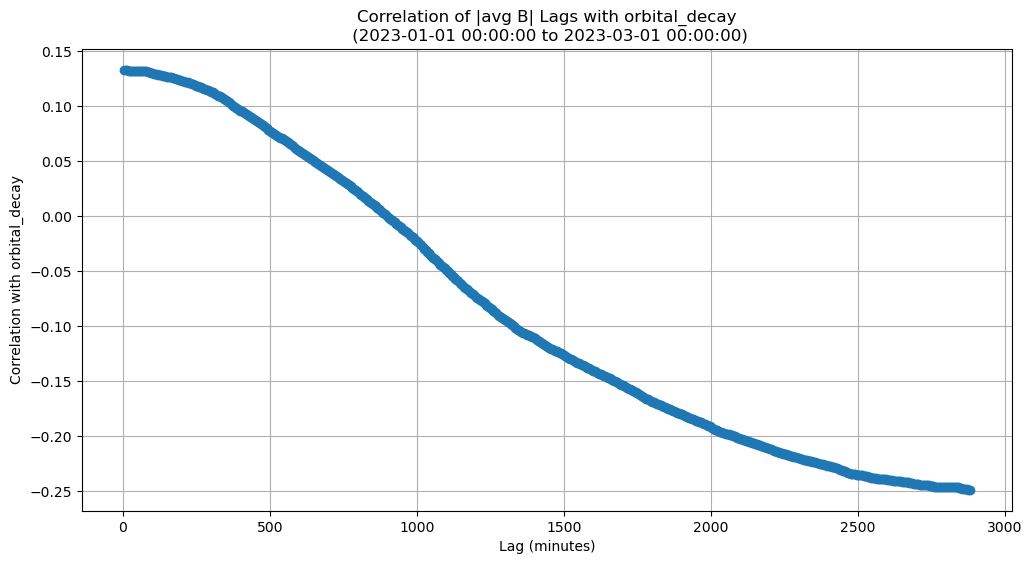

In [5]:
#-------------------Input-------------------------
feature = '|avg B|'
target = 'orbital_decay'
start_date = '2023-01-01 00:00:00'
end_date = '2023-03-01 00:00:00'
#-------------------------------------------------

# create subset
subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)].reset_index(drop=True)
# create lag features
subset_lag = LagFeatures(subset[[feature]], lag_minutes=5, max_lag_hours=48).df
# add target column
subset_lag[target] = subset[target].values

# Get lag columns
lag_cols = [c for c in subset_lag.columns if c.startswith(f'{feature}_Lag')]

# Fast correlation
correlations = fast_lag_correlation(subset_lag, lag_cols, target)

# Plot
lags = [int(c.split('Lag')[1]) * 5 for c in lag_cols]  # in minutes
plt.figure(figsize=(12, 6))
plt.plot(lags, correlations, marker='o')
plt.xlabel('Lag (minutes)')
plt.ylabel(f'Correlation with {target}')
plt.title(f'Correlation of {feature} Lags with {target}\n ({start_date} to {end_date})')
plt.grid(True)
plt.show()

# Test for different subsets

Total subsets: 30, each with size: 49535 points = 17.20 days


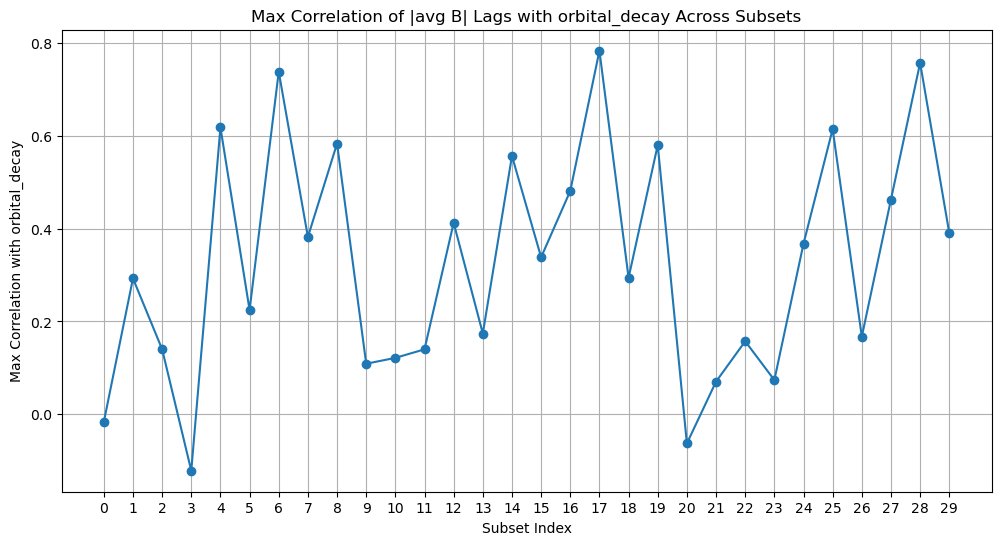

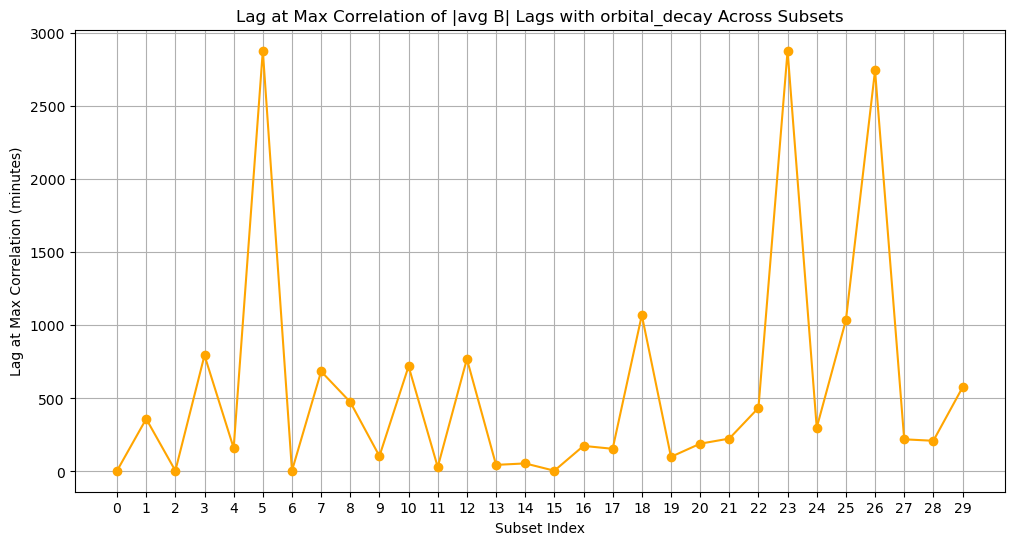

In [8]:
#-------------------Input-------------------------
feature = '|avg B|'
target = 'orbital_decay'
n = 30 # number of subsets to split the data into
#-------------------------------------------------

subset_size = len(GFOC_data[target]) // n
print(f"Total subsets: {n}, each with size: {subset_size} points = {subset_size / 120 / 24:.2f} days")
max_corr = [None] * n
lag_at_max = [None] * n
middle_data = [None] * n

for i in range(n):
    start_idx = i * subset_size
    # Make sure the last subset includes any remaining data
    end_idx = (i + 1) * subset_size if i < n - 1 else len(GFOC_data[target])
    subset = GFOC_data.iloc[start_idx:end_idx]

    # create lag features
    subset_lag = LagFeatures(subset[[feature]], lag_minutes=5, max_lag_hours=48).df
    # add target column
    subset_lag[target] = subset[target].values

    # Get lag columns
    lag_cols = [c for c in subset_lag.columns if c.startswith(f'{feature}_Lag')]

    # Fast correlation
    correlations = fast_lag_correlation(subset_lag, lag_cols, target)

    max_corr[i] = np.nanmax(correlations)
    lag_at_max[i] = (np.nanargmax(correlations) + 1) * 5
    middle_data[i] = subset['time'].iloc[len(subset) // 2]

# Plot max correlations
plt.figure(figsize=(12, 6))
plt.plot(range(n), max_corr, marker='o')
plt.xticks(range(n))
plt.xlabel('Subset Index')
plt.ylabel(f'Max Correlation with {target}')
plt.title(f'Max Correlation of {feature} Lags with {target} Across Subsets')
plt.grid(True)
plt.show()

# Plot lag at max correlations
plt.figure(figsize=(12, 6))
plt.plot(range(n), lag_at_max, marker='o', color='orange')
plt.xticks(range(n))
plt.xlabel('Subset Index')
plt.ylabel('Lag at Max Correlation (minutes)')
plt.title(f'Lag at Max Correlation of {feature} Lags with {target} Across Subsets')
plt.grid(True)
plt.show()

# Notes

- Vanessa pre-filters the data with Bz into three groups (Bz < 0, Bz < -5, Bz <9999)
- Depending on the strength of the event there are different propagation times for avg B.
- The correlation I calculated is still useful, as it shows the range of propagation times (lags) that occur in the dataset and therefore should be used in the model.